# Sesión 3 — SVM lineal y SVR

**Pregunta problema:** ¿cómo cambian la frontera, el margen y la predicción cuando el costo de violar el margen se controla explícitamente?

Primero veremos la geometría en 2D; después trasladaremos la idea del margen al tubo ε-insensible de SVR en InmoValor.

## Objetivos y contrato

Visualizar hiperplano, margen y vectores de soporte; interpretar `C`; comprobar por qué el escalamiento pertenece al pipeline; aplicar SVR lineal con el objetivo estandarizado y evaluar MAE sin ajustar con test.

In [1]:
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
warnings.filterwarnings("ignore", category=FutureWarning)

def locate_dataset():
    candidates = [
        Path("datasets/public/Ames_Housing.csv"),
        Path("../../datasets/public/Ames_Housing.csv"),
        Path("../datasets/public/Ames_Housing.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("No se encontró datasets/public/Ames_Housing.csv")

data_path = locate_dataset()
frame = pd.read_csv(data_path)
X = frame.drop(columns=["SalePrice", "Id"])
y = frame["SalePrice"].astype(float)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

def make_preprocessor(data):
    numeric = data.select_dtypes(include=np.number).columns.tolist()
    categorical = data.select_dtypes(exclude=np.number).columns.tolist()
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        # "Missing" conserva la semántica de amenidades ausentes y evita
        # eliminar columnas que estén completamente vacías dentro de un fold.
        ("imputer", SimpleImputer(
            strategy="constant", fill_value="Missing", keep_empty_features=True
        )),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipe, numeric),
        ("categorical", categorical_pipe, categorical),
    ])

def wrap(model, data=X_dev):
    return Pipeline([
        ("preprocess", make_preprocessor(data)),
        ("model", model),
    ])

print(f"Datos: {frame.shape[0]:,} viviendas, {X.shape[1]} predictores")
print(f"Desarrollo: {len(X_dev):,} | Test reservado: {len(X_test):,}")


from sklearn.datasets import make_blobs
from sklearn.svm import SVC, SVR

Datos: 1,460 viviendas, 79 predictores
Desarrollo: 1,168 | Test reservado: 292


## 1. Geometría bidimensional

Generamos dos grupos con solapamiento moderado. El ejemplo es didáctico: permite ver lo que 79 variables de Ames ocultarían.

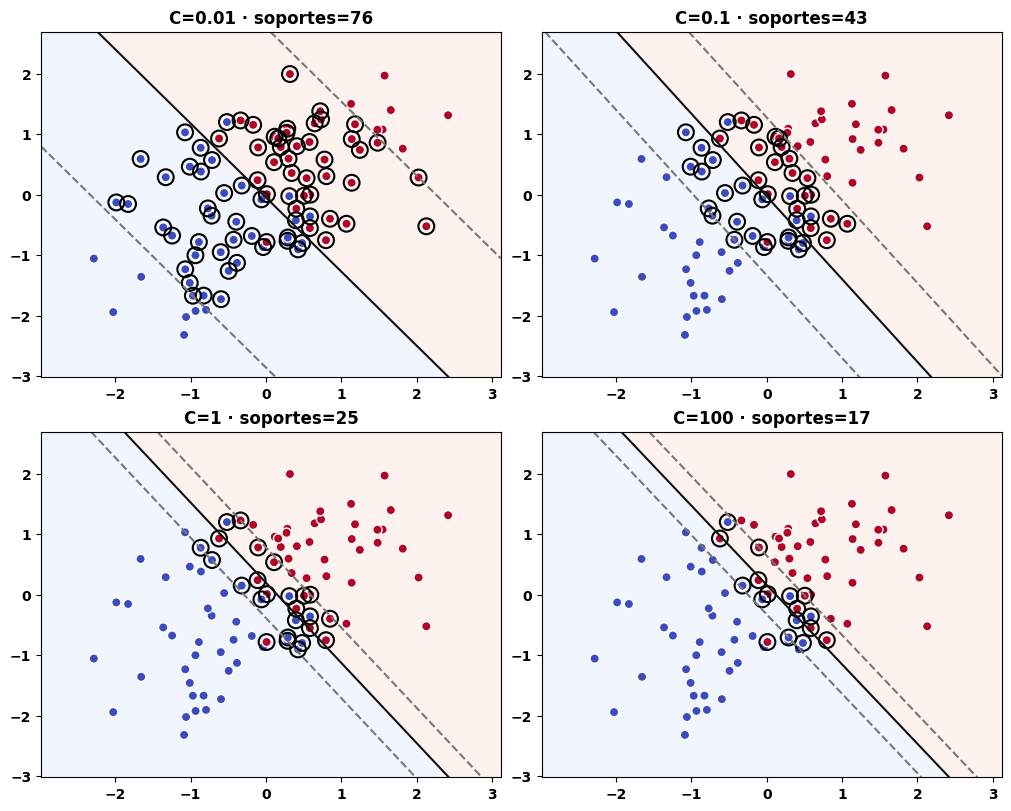

,C,vectores_soporte,accuracy_train
0,0.010,76,0.944
1,0.100,43,0.944
2,1.000,25,0.922
3,100.000,17,0.922


In [2]:
X_toy, y_toy = make_blobs(
    n_samples=90, centers=[(-1.2, -0.7), (1.1, 0.9)],
    cluster_std=[1.05, 1.05], random_state=7
)
toy_scaler = StandardScaler()
X_toy_scaled = toy_scaler.fit_transform(X_toy)

def plot_linear_svc(ax, model, X_values, y_values, title):
    x0 = np.linspace(X_values[:, 0].min() - 0.7, X_values[:, 0].max() + 0.7, 220)
    x1 = np.linspace(X_values[:, 1].min() - 0.7, X_values[:, 1].max() + 0.7, 220)
    xx, yy = np.meshgrid(x0, x1)
    decision = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, decision > 0, alpha=0.12, cmap="coolwarm")
    ax.contour(xx, yy, decision, levels=[-1, 0, 1],
               colors=["#777777", "#111111", "#777777"],
               linestyles=["--", "-", "--"])
    ax.scatter(X_values[:, 0], X_values[:, 1], c=y_values, cmap="coolwarm",
               edgecolor="white", s=45)
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    ax.set_title(title)

c_values = [0.01, 0.1, 1, 100]
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
support_rows = []
for ax, c_value in zip(axes.ravel(), c_values):
    svc = SVC(kernel="linear", C=c_value).fit(X_toy_scaled, y_toy)
    plot_linear_svc(ax, svc, X_toy_scaled, y_toy,
                    f"C={c_value} · soportes={len(svc.support_)}")
    support_rows.append({"C": c_value, "vectores_soporte": len(svc.support_),
                         "accuracy_train": svc.score(X_toy_scaled, y_toy)})
plt.show()
pd.DataFrame(support_rows)

### Lectura geométrica

`C` pequeño tolera más violaciones para favorecer un margen amplio. `C` grande penaliza con fuerza los casos dentro del margen o mal clasificados. El número de soportes es resultado de la geometría, no una métrica que deba minimizarse por sí sola.

## 2. El efecto del escalamiento

Multiplicamos una coordenada por 1 000. Es la misma información, pero la geometría numérica cambia. Compararemos un SVC directo con un pipeline que aprende el escalamiento dentro de cada ajuste.

In [3]:
X_distorted = X_toy.copy()
X_distorted[:, 0] *= 1000
unscaled = SVC(kernel="linear", C=1).fit(X_distorted, y_toy)
scaled_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1)),
]).fit(X_distorted, y_toy)
pd.DataFrame({
    "modelo": ["Sin escalar", "Pipeline escalado"],
    "accuracy_train": [unscaled.score(X_distorted, y_toy),
                       scaled_pipeline.score(X_distorted, y_toy)],
    "vectores_soporte": [len(unscaled.support_),
                         len(scaled_pipeline.named_steps["svc"].support_)],
})

,modelo,accuracy_train,vectores_soporte
0,Sin escalar,0.922,18
1,Pipeline escalado,0.922,25


## 3. Del margen al tubo ε-insensible

En SVR, errores dentro de `epsilon` no pagan pérdida. Escalaremos `SalePrice`, por lo que `epsilon` se interpreta inicialmente en desviaciones estándar y después evaluamos MAE nuevamente en dólares.

In [4]:
def make_target_scaled(model):
    return TransformedTargetRegressor(
        regressor=wrap(model),
        transformer=StandardScaler(),
    )

candidates = {
    "Baseline mediana": DummyRegressor(strategy="median"),
    "Ridge": make_target_scaled(Ridge(alpha=10.0)),
    "SVR C=0.1": make_target_scaled(SVR(kernel="linear", C=0.1, epsilon=0.10)),
    "SVR C=1": make_target_scaled(SVR(kernel="linear", C=1.0, epsilon=0.10)),
    "SVR C=10": make_target_scaled(SVR(kernel="linear", C=10.0, epsilon=0.10)),
}
rows = []
for name, candidate in candidates.items():
    started = time.perf_counter()
    scores = -cross_val_score(
        candidate, X_dev, y_dev,
        scoring="neg_mean_absolute_error", cv=CV, n_jobs=1,
    )
    rows.append({"modelo": name, "MAE_medio": scores.mean(),
                 "MAE_sd": scores.std(ddof=1),
                 "segundos": time.perf_counter() - started})
svr_results = pd.DataFrame(rows).sort_values("MAE_medio")
svr_results

,modelo,MAE_medio,MAE_sd,segundos
2,SVR C=0.1,"16,639.643","1,277.252",0.548
3,SVR C=1,"17,878.247","1,020.509",4.383
4,SVR C=10,"18,486.880",384.283,47.679
1,Ridge,"18,496.785",783.316,0.218
0,Baseline mediana,"54,547.639","2,711.807",0.050


## 4. Congelar configuración y abrir test

Seleccionamos por MAE medio de CV. Luego contamos los vectores de soporte si el ganador es SVR; solo los casos sobre o fuera del tubo determinan directamente la solución.

In [5]:
selected_name = svr_results.iloc[0]["modelo"]
selected = clone(candidates[selected_name]).fit(X_dev, y_dev)
prediction = selected.predict(X_test)
test_mae = mean_absolute_error(y_test, prediction)

support_count = np.nan
if selected_name.startswith("SVR"):
    fitted_svr = selected.regressor_.named_steps["model"]
    support_count = len(fitted_svr.support_)

pd.DataFrame({
    "modelo_congelado": [selected_name],
    "MAE_CV": [svr_results.iloc[0]["MAE_medio"]],
    "MAE_test": [test_mae],
    "vectores_soporte": [support_count],
})

,modelo_congelado,MAE_CV,MAE_test,vectores_soporte
0,SVR C=0.1,"16,639.643","16,627.846",708


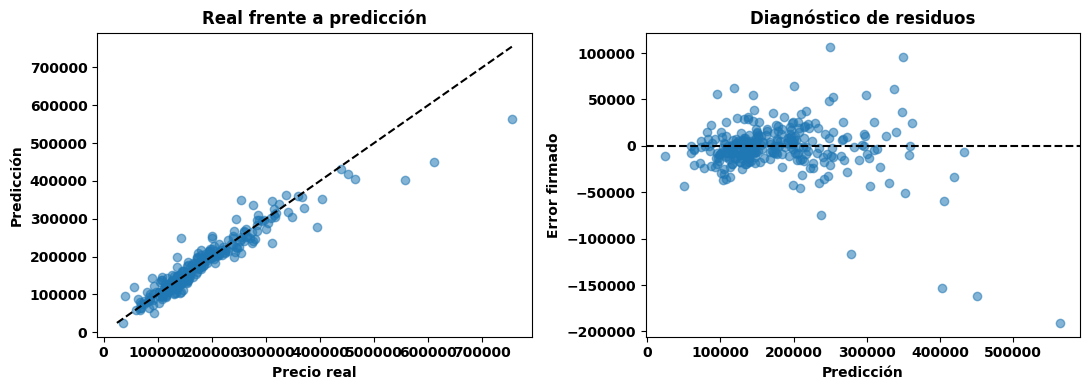

,real,predicción,error,error_absoluto
691,"755,000.000","564,168.850","-190,831.150","190,831.150"
898,"611,657.000","450,141.419","-161,515.581","161,515.581"
1046,"556,581.000","403,238.752","-153,342.248","153,342.248"
774,"395,000.000","278,583.031","-116,416.969","116,416.969"
588,"143,000.000","249,950.383","106,950.383","106,950.383"
581,"253,293.000","349,383.341","96,090.341","96,090.341"
218,"311,500.000","236,748.258","-74,751.742","74,751.742"
628,"135,000.000","199,874.778","64,874.778","64,874.778"


In [6]:
error_table = pd.DataFrame({
    "real": y_test,
    "predicción": prediction,
    "error": prediction - y_test,
})
error_table["error_absoluto"] = error_table["error"].abs()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(error_table["real"], error_table["predicción"], alpha=0.55)
limits = [error_table[["real", "predicción"]].min().min(),
          error_table[["real", "predicción"]].max().max()]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(xlabel="Precio real", ylabel="Predicción", title="Real frente a predicción")
axes[1].scatter(error_table["predicción"], error_table["error"], alpha=0.55)
axes[1].axhline(0, ls="--", color="black")
axes[1].set(xlabel="Predicción", ylabel="Error firmado", title="Diagnóstico de residuos")
plt.tight_layout()
plt.show()
error_table.nlargest(8, "error_absoluto")

## Interpretación obligatoria

- **Observo:** describa el efecto de `C` en margen, soportes y MAE.
- **Significa:** conecte regularización con tolerancia a violaciones.
- **Recomendaría:** compare SVR con baseline y Ridge.
- **Vigilaría:** costo de entrenamiento y viviendas con errores extremos.
- **No puedo concluir:** el tubo ε no es un intervalo de confianza ni la predicción reemplaza la valoración humana.

## Reto guiado

Mantenga `C` fijo y compare `epsilon` en `{0.03, 0.10, 0.25}`. Antes de ejecutar, prediga cómo cambiarán el número de soportes y el MAE. Explique por qué `epsilon` está expresado en la escala transformada del objetivo.

## Puente a la próxima semana

Una frontera lineal no representa todas las estructuras. El *kernel trick* permitirá trabajar con fronteras no lineales sin construir explícitamente todas las nuevas variables; después ajustaremos conjuntamente `C`, `gamma` y kernel.